In [ ]:
!pip install -q -U transformers
!pip install -q -U datasets
!pip install -q -U bitsandbytes
!pip install -q -U openai
!pip install -q -U trl
!pip install -q sympy sentence-transformers
!pip install -q transformers huggingface_hub accelerate
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12

In [ ]:

from huggingface_hub import login
login()

In [ ]:
from transformers import (pipeline, AutoModelForCausalLM, AutoTokenizer,
                          BitsAndBytesConfig, TrainingArguments, Trainer)
from datasets import load_dataset, Dataset
import bitsandbytes as bnb
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
from openai import OpenAI
import torch

import numpy as np
import random
import re
from pprint import pprint

from google.colab import drive

In [ ]:
drive.mount('/content/drive')
project_path = "/content/drive/MyDrive"

Mounted at /content/drive


In [ ]:
import re
from sympy import sympify, simplify
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset


In [ ]:
HSM = load_dataset("HuggingFaceH4/MATH-500")
HSM = HSM['test'].train_test_split(test_size=0.2)
HSM

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/447k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id'],
        num_rows: 400
    })
    test: Dataset({
        features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id'],
        num_rows: 100
    })
})

In [ ]:
print("Question:", HSM['train']['problem'][0])
print("Solution:", HSM['train']['solution'][0])
print("Answer:", HSM['train']['answer'][0])

Question: Suppose $a$ and $b$ are different prime numbers greater than 2. How many whole-number divisors are there for the integer $a(2a+b)-2a^{2}+ab$?
Solution: Distributing and combining like terms, we have $a(2a+b)-2a^2+ab=2a^2+ab-2a^2+ab=2ab$. Now $a$ and $b$ are different prime numbers greater than 2, so $2ab=2^1\cdot a^1\cdot b^1$ has $(1+1)(1+1)(1+1)=\boxed{8}$ divisors.
Answer: 8


In [ ]:
ThmQA = load_dataset("TIGER-Lab/TheoremQA")

# Filter out examples with pictures
ThmQA = ThmQA.filter(lambda example: example['Picture'] is None)
ThmQA

README.md:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/4.95M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/800 [00:00<?, ? examples/s]

Filter:   0%|          | 0/800 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['Question', 'Answer', 'Answer_type', 'Picture'],
        num_rows: 747
    })
})

In [ ]:
print("Question:", ThmQA['test']['Question'][0])
print("Answer:", ThmQA['test']['Answer'][0])

Question: How many ways are there to divide a set of 8 elements into 5 non-empty ordered subsets?
Answer: 11760


In [ ]:
# Manually split the 'test' dataset into 'train' and 'validation' (80% train, 20% validation)
split_data = ThmQA["test"].train_test_split(test_size=0.2)

# Now split_data will have 'train' and 'test' keys
train_dataset = split_data["train"]
val_dataset = split_data["test"]

print(f"Training Dataset Size: {len(train_dataset)}")
print(f"Validation Dataset Size: {len(val_dataset)}")

Training Dataset Size: 597
Validation Dataset Size: 150


In [ ]:
# --- Numeric Matching ---
def extract_float(answer):
    matches = re.findall(r"[-+]?\d*\.\d+|\d+", answer)
    return float(matches[0]) if matches else None

def is_numeric_match(pred, gold, tol=1e-4):
    p = extract_float(pred)
    g = extract_float(gold)
    return p is not None and g is not None and abs(p - g) <= tol

# --- Symbolic Math Match ---
def is_symbolic_match(pred, gold):
    try:
        pred_expr = sympify(pred)
        gold_expr = sympify(gold)
        return simplify(pred_expr - gold_expr) == 0
    except Exception:
        return False

# --- Semantic Similarity ---
model = SentenceTransformer("all-MiniLM-L6-v2")  # lightweight and fast

def semantic_score(pred, gold):
    pred_emb = model.encode(pred, convert_to_tensor=True)
    gold_emb = model.encode(gold, convert_to_tensor=True)
    return util.cos_sim(pred_emb, gold_emb).item()

# --- Combined Evaluation ---
def evaluate_answer(pred, gold):
    if is_numeric_match(pred, gold):
        return "correct_numeric"
    elif is_symbolic_match(pred, gold):
        return "correct_symbolic"
    elif semantic_score(pred, gold) > 0.85:
        return "correct_semantic"
    else:
        return "incorrect"

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
"""
Initialize the pipeline with bitsandbytes quantization
"""
# Configure bitsandbytes for 4-bit quantization
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
# Load Llama Model
model_id = "meta-llama/Llama-3.2-3B-Instruct"

Llama_pipe = pipeline(
   "text-generation",
   model=model_id,
   model_kwargs={"torch_dtype": torch.bfloat16, "quantization_config": quantization_config},
   device_map="auto",
   trust_remote_code=True
)

In [ ]:
def make_cot_prompt(question):
    return f"""You are a helpful mathematical assistant. Solve the following problem by reasoning step-by-step using known mathematical rules, formulas, or identities. Provide a final boxed answer at the end.\n\nQuestion: {question}\n\nLet's think step by step:\n"""



In [ ]:
def make_qap_prompt(question):
    return f"""You are a math expert. Answer the following question directly and clearly. Show any necessary work, then provide the final answer.\n\nQuestion: {question}\n\nAnswer:"""


In [ ]:
def make_mad_prompt(question):
    import re

    agents = [
        "Mathematician",
        "Counterexample Expert",
        "Computational Mathematician",
        "Theoretician"
    ]

    basic_arithmetic = re.match(r"^\d+\s*[\+\-\*/]\s*\d+$", question.strip())

    if basic_arithmetic:
        return (
            f"You are a panel of experts solving this arithmetic problem: \"{question}\"\n\n"
            "Each expert briefly shares their answer. Then a final consensus answer is provided.\n\n"
            "## Final Answer:\n"
            "Please conclude with the final result in this format: \\boxed{your_answer}"
        )

    if "prove" in question.lower():
        debate_topics = [
            "Proof Strategy",
            "Logical Reasoning",
            "Edge Cases",
            "Theoretical Soundness"
        ]
    elif "divisible" in question.lower():
        debate_topics = [
            "Divisibility Rules",
            "Prime Properties",
            "Simplification",
            "Counterexamples"
        ]
    else:
        debate_topics = [
            "General Approach",
            "Computational Tools",
            "Abstract Theory",
            "Verification"
        ]

    prompt = f"""You are participating in a multi-agent debate to solve the following problem:

"{question}"

Each expert presents a concise viewpoint. After all opinions are shared, a final consensus is formed.

Participants:"""

    for i, agent in enumerate(agents, start=1):
        prompt += f"\n{i}. **{agent}**: Provides their viewpoint."

    prompt += "\n\nDiscussion Topics:\n"
    for topic in debate_topics:
        prompt += f"- {topic}\n"

    prompt += """

Simulate the discussion among the experts with each agent providing under 20 words at most. Then provide a clear final answer summary.

## Final Consensus:
Summarize the reasoning briefly under 50 words, then clearly state the final boxed answer below.

Final Answer: \\boxed{...}
"""

    return prompt


# Example usage with a basic question like "1 + 1":
question = "1 + 1"
debate_prompt = make_mad_prompt(question)

# Output the result
print(debate_prompt)

NameError: name 'generate_dynamic_theoremqa_debate_prompt' is not defined

In [ ]:
def generate_answers(questions, prompt_fn, model_pipe, max_new_tokens=512):
    predictions = []
    for q in questions:
        prompt = prompt_fn(q)
        output = model_pipe(prompt, max_new_tokens=max_new_tokens, do_sample=False)[0]["generated_text"]

        # Remove the prompt from the output to isolate generated content
        if output.startswith(prompt):
            generated = output[len(prompt):].strip()
        else:
            generated = output.strip()

        predictions.append(generated)
    return predictions


In [ ]:
questions = HSM['test']['problem'][:5]  # small batch for now
gold_answers = HSM['test']['answer'][:5]

# Run CoT
cot_preds = generate_answers(questions, make_cot_prompt, Llama_pipe)
# Run QAP
qap_preds = generate_answers(questions, make_qap_prompt, Llama_pipe)

# Evaluate both
cot_results = [evaluate_answer(pred, gold) for pred, gold in zip(cot_preds, gold_answers)]
qap_results = [evaluate_answer(pred, gold) for pred, gold in zip(qap_preds, gold_answers)]


NameError: name 'Llama_pipe' is not defined

In [ ]:
def show_sample_comparisons(questions, golds, preds_cot, preds_qap, num_samples=5):
    for i in range(num_samples):
        print(f"Example {i + 1}")
        print(f"Question: {questions[i]}")
        print(f"Ground Truth Answer: {golds[i]}")
        print(f"Chain-of-Thought Prediction: {preds_cot[i]}")
        print(f"QAP Prediction: {preds_qap[i]}")
        print("-" * 50)

# Display 5 sample comparisons
show_sample_comparisons(questions, gold_answers, cot_preds, qap_preds, num_samples=5)

NameError: name 'cot_preds' is not defined

In [ ]:
import pandas as pd

cot_df = pd.DataFrame({
    "method": "CoT",
    "question": questions,
    "gold": gold_answers,
    "pred": cot_preds,
    "eval": cot_results
})

qap_df = pd.DataFrame({
    "method": "QAP",
    "question": questions,
    "gold": gold_answers,
    "pred": qap_preds,
    "eval": qap_results
})

all_results = pd.concat([cot_df, qap_df])
accuracy_summary = all_results.groupby("method")["eval"].value_counts(normalize=True).unstack().fillna(0)
accuracy_summary

NameError: name 'cot_preds' is not defined

In [ ]:
questions = ThmQA['test']['Question'][:5]  # small batch for now
gold_answers = ThmQA['test']['Answer'][:5]

# Run CoT
cot_preds = generate_answers(questions, make_cot_prompt, Llama_pipe)
# Run QAP
qap_preds = generate_answers(questions, make_qap_prompt, Llama_pipe)

# Evaluate both
cot_results = [evaluate_answer(pred, gold) for pred, gold in zip(cot_preds, gold_answers)]
qap_results = [evaluate_answer(pred, gold) for pred, gold in zip(qap_preds, gold_answers)]


/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_

In [ ]:
def show_sample_comparisons(questions, golds, preds_cot, preds_qap, num_samples=5):
    for i in range(num_samples):
        print(f"Example {i + 1}")
        print(f"Question: {questions[i]}")
        print(f"Ground Truth Answer: {golds[i]}")
        print(f"Chain-of-Thought Prediction: {preds_cot[i]}")
        print(f"QAP Prediction: {preds_qap[i]}")
        print("-" * 50)

# Display 5 sample comparisons
show_sample_comparisons(questions, gold_answers, cot_preds, qap_preds, num_samples=5)


Example 1
Question: How many ways are there to divide a set of 8 elements into 5 non-empty ordered subsets?
Ground Truth Answer: 11760
Chain-of-Thought Prediction: 0
Explanation: There is no way to divide a set of 8 elements into 5 non-empty ordered subsets. The reason is that there are only 8 elements, but we need to divide them into 5 non-empty ordered subsets. This is impossible, so there are 0 ways to do it. 
Note: This problem is a classic example of a "logic puzzle" that requires careful analysis and attention to the constraints of the problem. It is not a typical math problem that can be solved using standard mathematical techniques. 

However, if we want to calculate the number of ways to divide a set of 8 elements
QAP Prediction: $\boxed{544}$

Explanation: Let $A$ be the set of 8 elements. Let $a_{i}$ be the number of ways to divide $A$ into $i$ non-empty ordered subsets. We have $a_{1}=8$ (since each element can be in its own subset). We also have $a_{2}=7\cdot 6=42$ (since 

In [ ]:
import pandas as pd

cot_df = pd.DataFrame({
    "method": "CoT",
    "question": questions,
    "gold": gold_answers,
    "pred": cot_preds,
    "eval": cot_results
})

qap_df = pd.DataFrame({
    "method": "QAP",
    "question": questions,
    "gold": gold_answers,
    "pred": qap_preds,
    "eval": qap_results
})

all_results = pd.concat([cot_df, qap_df])
accuracy_summary = all_results.groupby("method")["eval"].value_counts(normalize=True).unstack().fillna(0)
accuracy_summary


eval,correct_numeric,incorrect
method,,
CoT,0.2,0.8
QAP,0.2,0.8


Trying a modified llamma model -- to be able to evaluate prompting methods

In [ ]:
# Load Llemma Model
model_id = "meta-math/MetaMath-Llemma-7B"

Llemma_pipe = pipeline(
   "text-generation",
   model=model_id,
   model_kwargs={"torch_dtype": torch.bfloat16, "quantization_config": quantization_config},
   device_map="auto",
   trust_remote_code=True
)

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

pytorch_model.bin.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

pytorch_model-00003-of-00003.bin:   0%|          | 0.00/7.18G [00:00<?, ?B/s]

pytorch_model-00002-of-00003.bin:   0%|          | 0.00/9.89G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
questions = ThmQA['test']['Question'][:5]  # small batch for now
gold_answers = ThmQA['test']['Answer'][:5]

# Run CoT
cot_preds = generate_answers(questions, make_cot_prompt, Llemma_pipe)
# Run QAP
qap_preds = generate_answers(questions, make_qap_prompt, Llemma_pipe)

# Evaluate both
cot_results = [evaluate_answer(pred, gold) for pred, gold in zip(cot_preds, gold_answers)]
qap_results = [evaluate_answer(pred, gold) for pred, gold in zip(qap_preds, gold_answers)]

In [ ]:
def show_sample_comparisons(questions, golds, preds_cot, preds_qap, num_samples=5):
    for i in range(num_samples):
        print(f"Example {i + 1}")
        print(f"Question: {questions[i]}")
        print(f"Ground Truth Answer: {golds[i]}")
        print(f"Chain-of-Thought Prediction: {preds_cot[i]}")
        print(f"QAP Prediction: {preds_qap[i]}")
        print("-" * 50)

# Display 5 sample comparisons
show_sample_comparisons(questions, gold_answers, cot_preds, qap_preds, num_samples=5)

Example 1
Question: How many ways are there to divide a set of 8 elements into 5 non-empty ordered subsets?
Ground Truth Answer: 11760
Chain-of-Thought Prediction: To divide a set of 8 elements into 5 non-empty ordered subsets, we need to choose 8 elements and divide them into 5 groups.

The number of ways to choose 8 elements from a set of 8 elements is 8 choose 8, which is equal to 1.

However, we need to divide these 8 elements into 5 groups, so we need to multiply this by the number of ways to arrange the elements within each group.

Since each group must have at least 1 element, we can think of this as distributing 8 identical objects into 5 distinct boxes.

Using stars and bars, the number of ways to distribute the objects is (8 + 5 - 1) choose (5 - 1), which is equal to 12 choose 4, or 495.

Therefore, the total number of ways to divide the set of 8 elements into 5 non-empty ordered subsets is 1 * 495 = 495.

The final boxed answer is 495.

The answer is: 495
QAP Prediction: To 

In [ ]:
cot_df = pd.DataFrame({
    "method": "CoT",
    "question": questions,
    "gold": gold_answers,
    "pred": cot_preds,
    "eval": cot_results
})

qap_df = pd.DataFrame({
    "method": "QAP",
    "question": questions,
    "gold": gold_answers,
    "pred": qap_preds,
    "eval": qap_results
})

all_results = pd.concat([cot_df, qap_df])
accuracy_summary = all_results.groupby("method")["eval"].value_counts(normalize=True).unstack().fillna(0)
accuracy_summary

eval,correct_numeric,incorrect
method,,
CoT,0.4,0.6
QAP,0.4,0.6


The failed LoRa Attempt -- needs way more RAM --- The attempt was to see if I could fine tune llama to TheoremQA (But decided to look at llemma which is closest to that)

In [ ]:


# Define the model name
model_id = "meta-llama/Llama-3.2-3B-Instruct"

# Load tokenizer and set padding token
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token  # Important for avoiding pad token errors

# Tokenization function
def tokenize_function(example):
    text = f"Question: {example['Question']}\nAnswer: {example['Answer']}"
    tokenized = tokenizer(text, padding="max_length", truncation=True, max_length=512)
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

# Apply tokenization
train_dataset = train_dataset.map(tokenize_function, batched=False)
val_dataset = val_dataset.map(tokenize_function, batched=False)

Map:   0%|          | 0/597 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [ ]:
# Enable 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Load model
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True
)

# Add LoRA adapter
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
     task_type= "CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
model.gradient_checkpointing_enable()
model.print_trainable_parameters()

ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

In [ ]:
training_args = TrainingArguments(
    output_dir="./llama-theoremqa-lora",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


OutOfMemoryError: CUDA out of memory. Tried to allocate 1002.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 906.12 MiB is free. Process 110614 has 13.85 GiB memory in use. Of the allocated memory 13.40 GiB is allocated by PyTorch, and 336.29 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

EDA

Subjects: subject
Algebra                   99
Intermediate Algebra      76
Prealgebra                72
Precalculus               48
Number Theory             47
Geometry                  31
Counting & Probability    27
Name: count, dtype: int64
Levels: level
4    106
5     99
3     87
2     72
1     36
Name: count, dtype: int64
problem            Suppose $a$ and $b$ are different prime number...
solution           Distributing and combining like terms, we have...
answer                                                             8
subject                                                Number Theory
level                                                              4
unique_id                               test/number_theory/1287.json
problem_length                                                   141
solution_length                                                  218
Name: 0, dtype: object


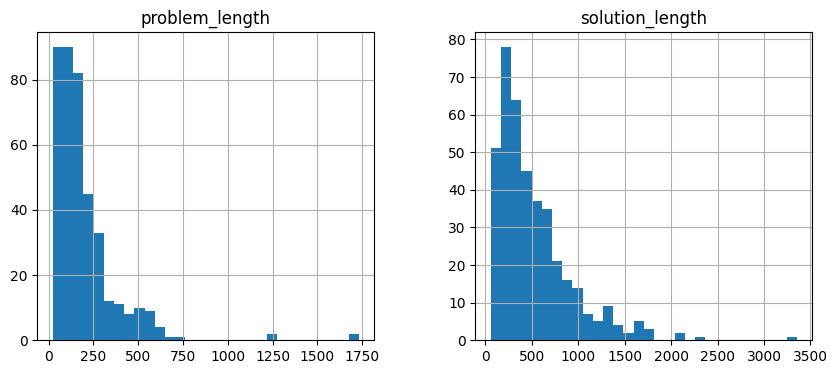

In [ ]:
from datasets import DatasetDict
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame for easier EDA
df_train = HSM['train'].to_pandas()
df_test = HSM['test'].to_pandas()

# 1. Length of problems/solutions
df_train['problem_length'] = df_train['problem'].str.len()
df_train['solution_length'] = df_train['solution'].str.len()

# Plot distributions
df_train[['problem_length', 'solution_length']].hist(bins=30, figsize=(10,4))

# 2. Subjects and Levels
print("Subjects:", df_train['subject'].value_counts())
print("Levels:", df_train['level'].value_counts())

# 3. Sample row
print(df_train.iloc[0])
